# Ridge & Lasso Regression

**Context:** Regularized linear models for high-dimensional panel data.
Regularization prevents the severe overfitting seen with unpenalized OLS
when the number of features is large relative to the training sample.

| Model | Penalty | Key property |
|-------|---------|-------------|
| Ridge | L2 — sum of squared coefficients | Shrinks all towards zero; handles multicollinearity |
| Lasso | L1 — sum of absolute coefficients | Sets some coefficients to exactly zero (feature selection) |

**Pipeline:** Load data → year-based train/val/test split → standardize features (train only)
→ grid-search alpha on validation OOS R² → evaluate on test → long-short portfolio → save results.

## Configuration

All tunable parameters are defined below. Modify these values to adapt the notebook to a new dataset.

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,
    # --- Ridge alpha grid ---
    'RIDGE_ALPHAS':       [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    # --- Lasso alpha grid ---
    'LASSO_ALPHAS':       [1e-4, 1e-3, 0.01, 0.1, 1.0],
    'LASSO_MAX_ITER':     5000,
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         'results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  RIDGE_ALPHAS: [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
  LASSO_ALPHAS: [0.0001, 0.001, 0.01, 0.1, 1.0]
  LASSO_MAX_ITER: 5000
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

warnings.filterwarnings('ignore')

# Make utils importable when running from models/supervised/
sys.path.insert(0, str(Path('../../').resolve()))
from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, annualized_sharpe, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
    build_portfolio_df,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df,
    date_col    = CONFIG['DATE_COL'],
    train_years = CONFIG['TRAIN_YEARS'],
    val_years   = CONFIG['VAL_YEARS'],
)

print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']}   — {split_info['val_end']}    ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']}   — {split_info['test_end']}    ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945   — 1956    (709 obs)
Test       : 1957   — 2022    (77,548 obs)


## Step 2 — Prepare Features & Standardize

In [4]:
X, y, feature_cols = prepare_panel_data(
    df,
    target_col   = CONFIG['TARGET_COL'],
    exclude_cols = [CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value   = CONFIG['MISSING_FILL_VALUE'],
)

# Split into periods
X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Drop rows where target is NaN
(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

# Standardize (fit on train only)
if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)

y_train_mean = float(y_train.mean())

print(f'Features      : {len(feature_cols)}')
print(f'Train obs     : {X_train.shape[0]:,}')
print(f'Val obs       : {X_val.shape[0]:,}')
print(f'Test obs      : {X_test.shape[0]:,}')
print(f'Training mean : {y_train_mean:.6f}')

Features      : 209
Train obs     : 884
Val obs       : 708
Test obs      : 77,205
Training mean : 0.007120


## Step 3 — Ridge: Grid Search over Alpha

Select the alpha that maximises **validation OOS R²**.
Test set is never used for tuning.

In [5]:
ridge_results = []

for alpha in CONFIG['RIDGE_ALPHAS']:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    val_pred  = model.predict(X_val)
    oos_r2    = compute_oos_r2(y_val, val_pred, y_train_mean)

    ridge_results.append({'alpha': alpha, 'oos_r2_val': oos_r2, 'model': model})
    print(f'  Ridge alpha={alpha:>10.4f}  |  Val OOS R² = {oos_r2*100:+.4f}%')

# Best by validation OOS R²
best_ridge = max(ridge_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest Ridge alpha = {best_ridge['alpha']}  (Val OOS R² = {best_ridge['oos_r2_val']*100:+.4f}%)")

  Ridge alpha=    0.0100  |  Val OOS R² = -403.2363%
  Ridge alpha=    0.1000  |  Val OOS R² = -402.2708%
  Ridge alpha=    1.0000  |  Val OOS R² = -393.1886%


  Ridge alpha=   10.0000  |  Val OOS R² = -332.5845%
  Ridge alpha=  100.0000  |  Val OOS R² = -131.8140%
  Ridge alpha= 1000.0000  |  Val OOS R² = +8.2505%

Best Ridge alpha = 1000.0  (Val OOS R² = +8.2505%)


In [6]:
ridge_model = best_ridge['model']

ridge_preds = {
    'train': ridge_model.predict(X_train),
    'val':   ridge_model.predict(X_val),
    'test':  ridge_model.predict(X_test),
}

ridge_metrics = evaluate_splits(
    y_train, ridge_preds['train'],
    y_val,   ridge_preds['val'],
    y_test,  ridge_preds['test'],
    train_mean = y_train_mean,
)

print('RIDGE — BEST MODEL EVALUATION')
print('=' * 50)
print(f"  Alpha          : {best_ridge['alpha']}")
print(f"  Features       : {len(feature_cols)}")
print(f"  Standardized   : {CONFIG['STANDARDIZE']}")
print()
print(f"  Train R²       : {ridge_metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {ridge_metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {ridge_metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {ridge_metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {ridge_metrics['oos_r2_test']*100:+.4f}%")
print('=' * 50)

RIDGE — BEST MODEL EVALUATION
  Alpha          : 1000.0
  Features       : 209
  Standardized   : True

  Train R²       : +19.1904%
  Val R²         : +6.6119%
  Test R²        : -397.3133%

  OOS R² Val     : +8.2505%
  OOS R² Test    : -394.5400%


## Step 4 — Lasso: Grid Search over Alpha

Lasso (L1) can drive coefficients to exactly zero, providing automatic feature selection.
Grid search selects alpha by validation OOS R².

In [7]:
lasso_results = []

for alpha in CONFIG['LASSO_ALPHAS']:
    model = Lasso(alpha=alpha, max_iter=CONFIG['LASSO_MAX_ITER'])
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    oos_r2   = compute_oos_r2(y_val, val_pred, y_train_mean)
    n_nonzero = int(np.sum(model.coef_ != 0))

    lasso_results.append({'alpha': alpha, 'oos_r2_val': oos_r2, 'n_nonzero': n_nonzero, 'model': model})
    print(f'  Lasso alpha={alpha:>8.4f}  |  Val OOS R² = {oos_r2*100:+.4f}%  |  Non-zero coefs = {n_nonzero}/{len(feature_cols)}')

best_lasso = max(lasso_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest Lasso alpha = {best_lasso['alpha']}  (Val OOS R² = {best_lasso['oos_r2_val']*100:+.4f}%,  non-zero = {best_lasso['n_nonzero']})")

  Lasso alpha=  0.0001  |  Val OOS R² = -328.6446%  |  Non-zero coefs = 55/209
  Lasso alpha=  0.0010  |  Val OOS R² = -32.2259%  |  Non-zero coefs = 31/209
  Lasso alpha=  0.0100  |  Val OOS R² = +18.4750%  |  Non-zero coefs = 4/209
  Lasso alpha=  0.1000  |  Val OOS R² = +0.0000%  |  Non-zero coefs = 0/209
  Lasso alpha=  1.0000  |  Val OOS R² = +0.0000%  |  Non-zero coefs = 0/209

Best Lasso alpha = 0.01  (Val OOS R² = +18.4750%,  non-zero = 4)


In [8]:
lasso_model = best_lasso['model']

lasso_preds = {
    'train': lasso_model.predict(X_train),
    'val':   lasso_model.predict(X_val),
    'test':  lasso_model.predict(X_test),
}

lasso_metrics = evaluate_splits(
    y_train, lasso_preds['train'],
    y_val,   lasso_preds['val'],
    y_test,  lasso_preds['test'],
    train_mean = y_train_mean,
)

# Sparsity analysis
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lasso_model.coef_,
})
nonzero_coef_df = coef_df[coef_df['coefficient'] != 0].sort_values('coefficient', key=abs, ascending=False)

print('LASSO — BEST MODEL EVALUATION')
print('=' * 50)
print(f"  Alpha          : {best_lasso['alpha']}")
print(f"  Non-zero coefs : {best_lasso['n_nonzero']} / {len(feature_cols)}")
print(f"  Sparsity       : {(1 - best_lasso['n_nonzero']/len(feature_cols))*100:.1f}% zeroed out")
print()
print(f"  Train R²       : {lasso_metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {lasso_metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {lasso_metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {lasso_metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {lasso_metrics['oos_r2_test']*100:+.4f}%")
print('=' * 50)
print(f"\nTop 10 Lasso features (by |coefficient|):")
print(nonzero_coef_df.head(10).to_string(index=False))

LASSO — BEST MODEL EVALUATION
  Alpha          : 0.01
  Non-zero coefs : 4 / 209
  Sparsity       : 98.1% zeroed out

  Train R²       : +15.9963%
  Val R²         : +17.0189%
  Test R²        : +13.4702%

  OOS R² Val     : +18.4750%
  OOS R² Test    : +13.9528%

Top 10 Lasso features (by |coefficient|):
     feature  coefficient
      High52     0.019500
  ReturnSkew    -0.009822
ReturnSkew3F    -0.006072
      MaxRet    -0.000527


## Step 5 — Model Comparison & Visualizations

In [9]:
comparison = pd.DataFrame([
    {
        'Model':        'Ridge',
        'Best alpha':   best_ridge['alpha'],
        'Non-zero':     f"{len(feature_cols)}/{len(feature_cols)}",
        'Train R²':     f"{ridge_metrics['r2_train']*100:+.3f}%",
        'Val R²':       f"{ridge_metrics['r2_val']*100:+.3f}%",
        'OOS R² Test':  f"{ridge_metrics['oos_r2_test']*100:+.3f}%",
    },
    {
        'Model':        'Lasso',
        'Best alpha':   best_lasso['alpha'],
        'Non-zero':     f"{best_lasso['n_nonzero']}/{len(feature_cols)}",
        'Train R²':     f"{lasso_metrics['r2_train']*100:+.3f}%",
        'Val R²':       f"{lasso_metrics['r2_val']*100:+.3f}%",
        'OOS R² Test':  f"{lasso_metrics['oos_r2_test']*100:+.3f}%",
    },
])
print(comparison.to_string(index=False))

Model  Best alpha Non-zero Train R²   Val R² OOS R² Test
Ridge     1000.00  209/209 +19.190%  +6.612%   -394.540%
Lasso        0.01    4/209 +15.996% +17.019%    +13.953%


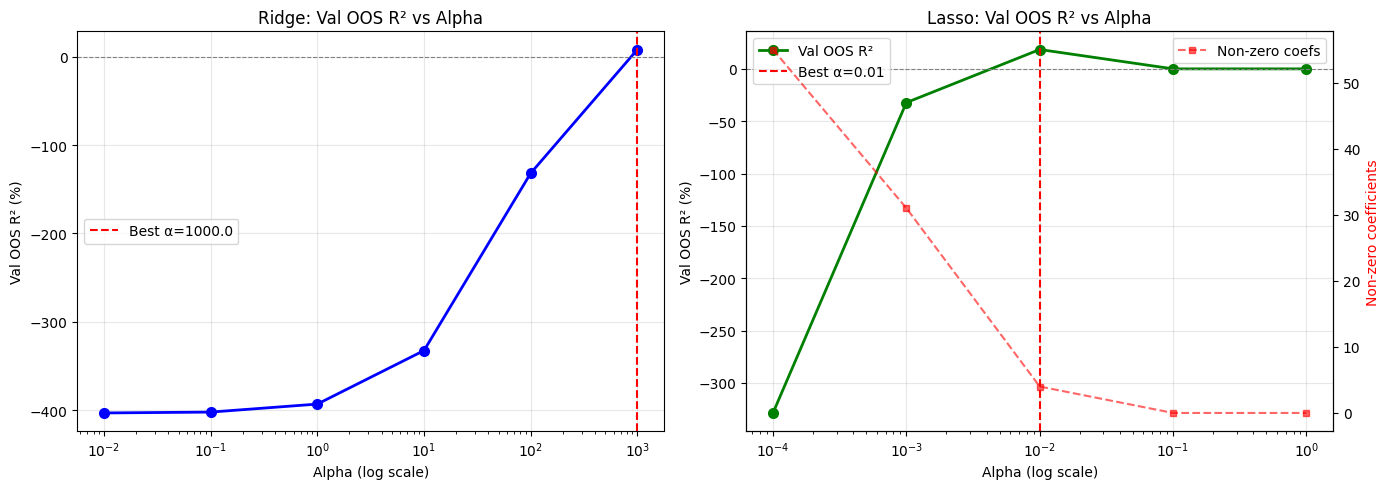

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge: OOS R² vs alpha
ridge_alphas  = [r['alpha'] for r in ridge_results]
ridge_oos_r2s = [r['oos_r2_val'] * 100 for r in ridge_results]
axes[0].semilogx(ridge_alphas, ridge_oos_r2s, 'b-o', linewidth=2, markersize=7)
axes[0].axvline(x=best_ridge['alpha'], color='red', linestyle='--', label=f"Best α={best_ridge['alpha']}")
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Val OOS R² (%)')
axes[0].set_title('Ridge: Val OOS R² vs Alpha')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lasso: OOS R² vs alpha
lasso_alphas  = [r['alpha'] for r in lasso_results]
lasso_oos_r2s = [r['oos_r2_val'] * 100 for r in lasso_results]
lasso_nonzero = [r['n_nonzero'] for r in lasso_results]
ax2 = axes[1]
ax2.semilogx(lasso_alphas, lasso_oos_r2s, 'g-o', linewidth=2, markersize=7, label='Val OOS R²')
ax2.axvline(x=best_lasso['alpha'], color='red', linestyle='--', label=f"Best α={best_lasso['alpha']}")
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Alpha (log scale)')
ax2.set_ylabel('Val OOS R² (%)')
ax2.set_title('Lasso: Val OOS R² vs Alpha')
ax_twin = ax2.twinx()
ax_twin.semilogx(lasso_alphas, lasso_nonzero, 'r--s', linewidth=1.5, markersize=5, alpha=0.6, label='Non-zero coefs')
ax_twin.set_ylabel('Non-zero coefficients', color='red')
ax2.legend(loc='upper left')
ax_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Portfolio Formation & Sharpe Ratio

Each month, rank stocks by predicted return, go long the top decile and short the bottom decile.

In [11]:
# Reconstruct test DataFrame with date, id, actual return, and predictions
test_df_base = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()

# Ridge portfolio
ridge_port_df = test_df_base.copy()
ridge_port_df['predicted_ret'] = ridge_preds['test']
ridge_port_df = ridge_port_df.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

ridge_returns, ridge_comp_df = form_long_short_portfolio(
    ridge_port_df,
    date_col  = CONFIG['DATE_COL'],
    pred_col  = 'predicted_ret',
    ret_col   = 'actual_ret',
    n_deciles = CONFIG['N_DECILES'],
)
ridge_port_stats = portfolio_summary(ridge_returns)

print('RIDGE LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months          : {ridge_port_stats['n_periods']}")
print(f"  Mean monthly    : {ridge_port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly     : {ridge_port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)   : {ridge_port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

RIDGE LONG-SHORT PORTFOLIO
  Months          : 552
  Mean monthly    : 6.8920%
  Std monthly     : 6.9986%
  Sharpe (ann.)   : 3.4113


In [12]:
# Lasso portfolio
lasso_port_df = test_df_base.copy()
lasso_port_df['predicted_ret'] = lasso_preds['test']
lasso_port_df = lasso_port_df.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

lasso_returns, lasso_comp_df = form_long_short_portfolio(
    lasso_port_df,
    date_col  = CONFIG['DATE_COL'],
    pred_col  = 'predicted_ret',
    ret_col   = 'actual_ret',
    n_deciles = CONFIG['N_DECILES'],
)
lasso_port_stats = portfolio_summary(lasso_returns)

print('LASSO LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months          : {lasso_port_stats['n_periods']}")
print(f"  Mean monthly    : {lasso_port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly     : {lasso_port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)   : {lasso_port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

LASSO LONG-SHORT PORTFOLIO
  Months          : 552
  Mean monthly    : 10.9074%
  Std monthly     : 7.7053%
  Sharpe (ann.)   : 4.9037


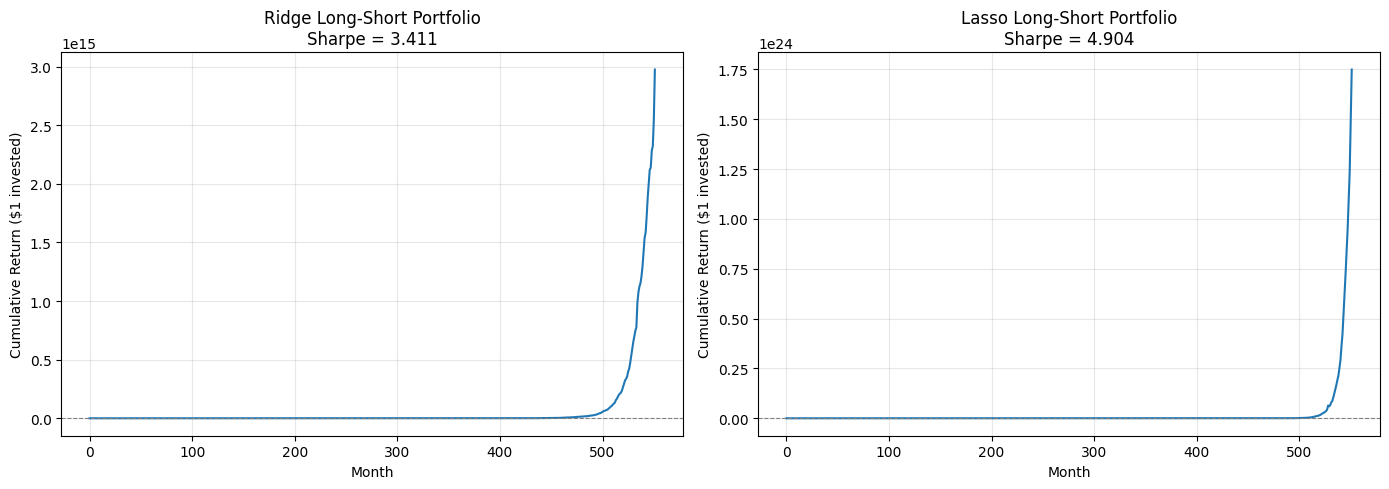

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, returns, label, stats in [
    (axes[0], ridge_returns, 'Ridge', ridge_port_stats),
    (axes[1], lasso_returns, 'Lasso', lasso_port_stats),
]:
    cumulative = (1 + returns).cumprod()
    ax.plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
    ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Month')
    ax.set_ylabel('Cumulative Return ($1 invested)')
    ax.set_title(f'{label} Long-Short Portfolio\nSharpe = {stats["sharpe_annualized"]:.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7 — Save Results

In [14]:
if CONFIG['SAVE_RESULTS']:

    # Ridge summary
    ridge_summary = build_run_summary(
        model_name    = 'Ridge',
        description   = 'Ridge Regression (L2 regularization)',
        tuning_params = f"alpha={best_ridge['alpha']}",
        metrics       = ridge_metrics,
        portfolio_stats = ridge_port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'ridge_lasso',
    )
    path = save_run_summary(ridge_summary, CONFIG['OUTPUT_DIR'], 'ridge_summary.csv')
    print(f'Saved: {path}')

    path = save_portfolio_compositions(ridge_comp_df, CONFIG['OUTPUT_DIR'], 'ridge_portfolios.csv')
    print(f'Saved: {path}')

    # Lasso summary
    lasso_summary = build_run_summary(
        model_name    = 'Lasso',
        description   = 'Lasso Regression (L1 regularization)',
        tuning_params = f"alpha={best_lasso['alpha']}, n_nonzero={best_lasso['n_nonzero']}",
        metrics       = lasso_metrics,
        portfolio_stats = lasso_port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'ridge_lasso',
    )
    path = save_run_summary(lasso_summary, CONFIG['OUTPUT_DIR'], 'lasso_summary.csv')
    print(f'Saved: {path}')

    path = save_portfolio_compositions(lasso_comp_df, CONFIG['OUTPUT_DIR'], 'lasso_portfolios.csv')
    print(f'Saved: {path}')

else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/ridge_summary.csv
Saved: results/ridge_portfolios.csv
Saved: results/lasso_summary.csv


Saved: results/lasso_portfolios.csv
